In [123]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay, confusion_matrix, precision_score, roc_auc_score, RocCurveDisplay, recall_score

#### Load Dataframe:

In [124]:
df = pd.read_csv(r"C:\Users\Masters Computer\Desktop\VScode_For_ Python\internship\project1\Data\synthetic_heart_disease_dataset.csv", keep_default_na=False)
df.head(3)

,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,Hypertension,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
0,48,Male,78,157,26.4,Never,None,Sedentary,Healthy,Medium,0,0,1,1,0,104,99,71,165,200,0
1,35,Female,73,163,33.0,Never,Low,Active,Average,High,1,0,1,1,0,111,72,60,145,206,0
2,79,Female,88,152,32.3,Never,None,Moderate,Average,Medium,0,0,0,1,0,116,102,78,148,208,0


#### Engineered Features: 

##### Pulse pressure:

- It represents the difference between systolic and diastolic blood pressure.

In [125]:
df['Pulse_Pressure'] = df['Systolic_BP'] - df['Diastolic_BP']

##### Mean arterial pressure:
- combines systolic and diastolic pressure into one average pressure value.

In [126]:
df['Mean_Arterial_Pressure'] = (df['Systolic_BP'] + 2 * df['Diastolic_BP']) / 3

##### Age groups:
- Captures age in groups rather than only assuming that every one-year increase behaves the same way.

In [127]:
label=['30-39', '40-49', '50-59', '60-69', '70-79']
bin=[29, 39, 49, 59, 69, 79]

df['Age_Group'] = pd.cut(df['Age'], bins=bin, labels=label)

##### BMI category:
- Divides BMI levels into common labels.

In [128]:
label1=['Underweight', 'Normal', 'Overweight', 'Obese']
bin1 = [0, 18.5, 25, 30, float('inf')]

df['BMI_Category'] = pd.cut( df['BMI'] , bins=bin1 , labels=label1 , right=False)

##### Number of existing medical risk conditions:
- Represents the number of recorded medical risk conditions.

In [129]:
df['Medical_Risk_Count'] = (df['Hypertension']+ df['Diabetes'] + df['Hyperlipidemia'] + df['Family_History'] + df['Previous_Heart_Attack'])

#### Check engineered features:

In [130]:
engineered_cols = [
    'Pulse_Pressure',
    'Mean_Arterial_Pressure',
    'Age_Group',
    'BMI_Category',
    'Medical_Risk_Count'
]

display(df[engineered_cols].head())
print('\nMissing values in engineered features:')
print(df[engineered_cols].isna().sum())

,Pulse_Pressure,Mean_Arterial_Pressure,Age_Group,BMI_Category,Medical_Risk_Count
0,5,100.666667,40-49,Overweight,2
1,39,85.000000,30-39,Obese,3
2,14,106.666667,70-79,Obese,1
3,79,118.333333,70-79,Obese,1
4,97,99.333333,30-39,Normal,2



Missing values in engineered features:
Pulse_Pressure            0
Mean_Arterial_Pressure    0
Age_Group                 0
BMI_Category              0
Medical_Risk_Count        0
dtype: int64


##### Simple statistics:
This gives a quick look at the numerical engineered features and how they differ between the two target classes.

In [131]:
numerical_engineered = [
    'Pulse_Pressure',
    'Mean_Arterial_Pressure',
    'Medical_Risk_Count'
]

print(df[numerical_engineered].describe().round(2))

print('\nAverage values by Heart_Disease:')
print(df.groupby('Heart_Disease', observed=False)[numerical_engineered].mean().round(2))

       Pulse_Pressure  Mean_Arterial_Pressure  Medical_Risk_Count
count        50000.00                50000.00            50000.00
mean            49.77                  106.12                1.25
std             28.86                   13.82                0.94
min            -19.00                   73.33                0.00
25%             29.00                   96.00                1.00
50%             50.00                  106.00                1.00
75%             71.00                  116.33                2.00
max            119.00                  139.00                5.00

Average values by Heart_Disease:
               Pulse_Pressure  Mean_Arterial_Pressure  Medical_Risk_Count
Heart_Disease                                                            
0                       49.84                  106.09                0.88
1                       49.70                  106.15                1.68


#### Engineered feature plots:

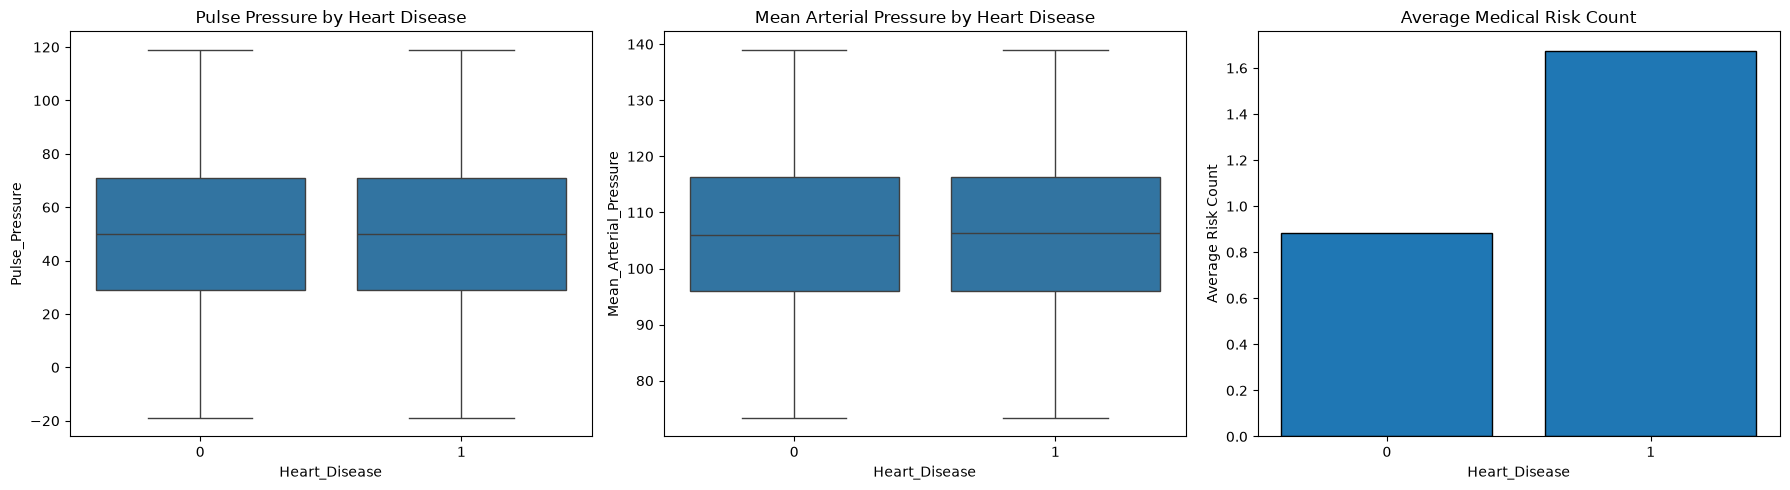

In [132]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='Heart_Disease', y='Pulse_Pressure', ax=axes[0])
axes[0].set_title('Pulse Pressure by Heart Disease')

sns.boxplot(data=df, x='Heart_Disease', y='Mean_Arterial_Pressure', ax=axes[1])
axes[1].set_title('Mean Arterial Pressure by Heart Disease')

risk_means = df.groupby('Heart_Disease')['Medical_Risk_Count'].mean()

axes[2].bar(risk_means.index.astype(str), risk_means.values, edgecolor='black')
axes[2].set_title('Average Medical Risk Count')
axes[2].set_xlabel('Heart_Disease')
axes[2].set_ylabel('Average Risk Count')

plt.tight_layout()
plt.show()

#### Preprocessing, Pipelines & Cross validation:

The categorical columns will be one-hot encoded and the numerical columns will be scaled inside the pipeline.

Doing the preprocessing inside the pipeline keeps the same preprocessing steps during training and cross-validation.

##### Train \ Test split:

In [133]:
X = df.drop(columns='Heart_Disease')
y = df['Heart_Disease']

# split before fitting any preprocessing
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42, stratify=y)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape:  {X_test.shape}")

Training shape: (40000, 25)
Testing shape:  (10000, 25)


##### Seperate Categorical & numerical columns to use with column transformer 

In [134]:
categorical_cols = X_train.select_dtypes(include=['str','object', 'string', 'category']).columns.tolist()


numerical_cols = X_train.select_dtypes(include=['int64','float64','number']).columns.tolist()

print("categorical columns name: ")
print(categorical_cols)

print("\nnumerical columns name: ")
print(numerical_cols)

categorical columns name: 
['Gender', 'Smoking', 'Alcohol_Intake', 'Physical_Activity', 'Diet', 'Stress_Level', 'Age_Group', 'BMI_Category']

numerical columns name: 
['Age', 'Weight', 'Height', 'BMI', 'Hypertension', 'Diabetes', 'Hyperlipidemia', 'Family_History', 'Previous_Heart_Attack', 'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'Blood_Sugar_Fasting', 'Cholesterol_Total', 'Pulse_Pressure', 'Mean_Arterial_Pressure', 'Medical_Risk_Count']


##### ColumnTransformer

In [135]:
#  transofrmer that includes engineered features.
preprocessor = ColumnTransformer([("num", StandardScaler(), numerical_cols) ,
                                 ( "cat",  OneHotEncoder(handle_unknown="ignore"),  categorical_cols) ])


### Original features vs engineered features

Before tuning the model, I will compare the same Random Forest with and without the engineered features.

This helps check if the added features actually improve the model.

In [136]:
original_feature_cols = [col for col in X.columns if col not in engineered_cols] # the original columns

X_train_original = X_train[original_feature_cols] #x_train only having the original columns
X_test_original = X_test[original_feature_cols]   #x_test only having the original columns

original_cat_cols = X_train_original.select_dtypes(include=['object', 'string', 'category']).columns.tolist() # list of categorical columns(original)
original_num_cols = X_train_original.select_dtypes(include=['number']).columns.tolist()                       # list of numerical columns(original)

original_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), original_num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), original_cat_cols) ]) # columntransformer that takes the original columns


original_pipe = Pipeline([
    ('preprocessor', original_preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

engineered_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)) # a pipe that uses the columntransformer that has (engineered features))
])

##### 5-fold cross-validation comparison:

In [137]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

original_scores = cross_val_score(original_pipe, X_train_original, y_train, cv=cv, scoring='f1', n_jobs=-1)

engineered_scores = cross_val_score( engineered_pipe, X_train, y_train,cv=cv, scoring='f1', n_jobs=-1)

print('Original features CV F1 scores:  ', original_scores)
print('Engineered features CV F1 scores:', engineered_scores)

print(f'\nOriginal mean CV F1:   {original_scores.mean():.4f}')
print(f'Engineered mean CV F1: {engineered_scores.mean():.4f}')
print(f'Improvement:            {engineered_scores.mean() - original_scores.mean():.4f}')
print(f'Engineered CV std:      {engineered_scores.std():.4f}')

Original features CV F1 scores:   [1. 1. 1. 1. 1.]
Engineered features CV F1 scores: [1. 1. 1. 1. 1.]

Original mean CV F1:   1.0000
Engineered mean CV F1: 1.0000
Improvement:            0.0000
Engineered CV std:      0.0000


##### Random Forest tuning

The engineered-feature pipeline is tuned using a small grid to keep the training time reasonable.

In [138]:
rf_pipe = Pipeline([('preprocessor', preprocessor) , ('model', RandomForestClassifier(random_state=42, n_jobs=-1))])

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5,10, None],
    'model__min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(rf_pipe, param_grid=param_grid, cv=cv, scoring='f1', n_jobs=-1)

grid_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [5, 10, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",Tr

In [139]:
print('Best Random Forest parameters:')
print(grid_rf.best_params_)

print(f'\nBest CV F1: {grid_rf.best_score_:.4f}')

Best Random Forest parameters:
{'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Best CV F1: 1.0000


#### Logistic Regression pipeline

I added Logistic Regression as another model to compare with the tuned Random Forest using the same engineered features and preprocessing.

In [140]:
lr_pipe = Pipeline([('preprocessor', preprocessor),('model', LogisticRegression(max_iter=1000, random_state=42))])

lr_scores = cross_val_score(lr_pipe, X_train, y_train,cv=cv, scoring='f1', n_jobs=-1)

lr_pipe.fit(X_train, y_train)

print('Logistic Regression CV F1 scores:', lr_scores)
print(f'Logistic Regression mean CV F1: {lr_scores.mean():.4f}')
print(f'Logistic Regression CV std:     {lr_scores.std():.4f}')

Logistic Regression CV F1 scores: [0.94386862 0.9433557  0.94636632 0.94504021 0.94428706]
Logistic Regression mean CV F1: 0.9446
Logistic Regression CV std:     0.0010


### Final test evaluation

The test set was kept separate from cross-validation and tuning. It is used here for the final comparison.

In [141]:
# fit the untuned models for a fair test comparison

original_pipe.fit(X_train_original, y_train)
engineered_pipe.fit(X_train, y_train)

pred_original   = original_pipe.predict(X_test_original)
pred_engineered = engineered_pipe.predict(X_test)

best_rf = grid_rf.best_estimator_

pred_rf = best_rf.predict(X_test)
pred_lr = lr_pipe.predict(X_test)

prob_original = original_pipe.predict_proba(X_test_original)[:, 1]

prob_engineered = engineered_pipe.predict_proba(X_test)[:, 1]

prob_rf = best_rf.predict_proba(X_test)[:, 1]

prob_lr = lr_pipe.predict_proba(X_test)[:, 1]


print('- Tuned Random Forest -')
print(classification_report(y_test, pred_rf))

print('- Logistic Regression -')
print(classification_report(y_test, pred_lr))

- Tuned Random Forest -
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5365
           1       1.00      1.00      1.00      4635

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000

- Logistic Regression -
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      5365
           1       0.94      0.94      0.94      4635

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



#### Metrics comparison:

In [150]:
results = pd.DataFrame({
    'Model': [
        'Random Forest - Original',
        'Random Forest - Engineered',
        'Random Forest - Tuned',
        'Logistic Regression - Engineered'
    ],
    'CV F1': [
        original_scores.mean(),
        engineered_scores.mean(),
        grid_rf.best_score_,
        lr_scores.mean()
    ],
    'Accuracy': [
        accuracy_score(y_test, pred_original),
        accuracy_score(y_test, pred_engineered),
        accuracy_score(y_test, pred_rf),
        accuracy_score(y_test, pred_lr)
    ],
    'Precision': [
        precision_score(y_test, pred_original),
        precision_score(y_test, pred_engineered),
        precision_score(y_test, pred_rf),
        precision_score(y_test, pred_lr)
    ],
    'Recall': [
        recall_score(y_test, pred_original),
        recall_score(y_test, pred_engineered),
        recall_score(y_test, pred_rf),
        recall_score(y_test, pred_lr)
    ],
    'F1': [
        f1_score(y_test, pred_original),
        f1_score(y_test, pred_engineered),
        f1_score(y_test, pred_rf),
        f1_score(y_test, pred_lr)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, prob_original),
        roc_auc_score(y_test, prob_engineered),
        roc_auc_score(y_test, prob_rf),
        roc_auc_score(y_test, prob_lr)
    ]
})

results.round(4)

,Model,CV F1,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest - Original,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,Random Forest - Engineered,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,Random Forest - Tuned,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,Logistic Regression - Engineered,0.9446,0.9441,0.9362,0.9437,0.9399,0.9882


#### Test metrics graph:

This makes it easier to compare the main test metrics between the experiments.

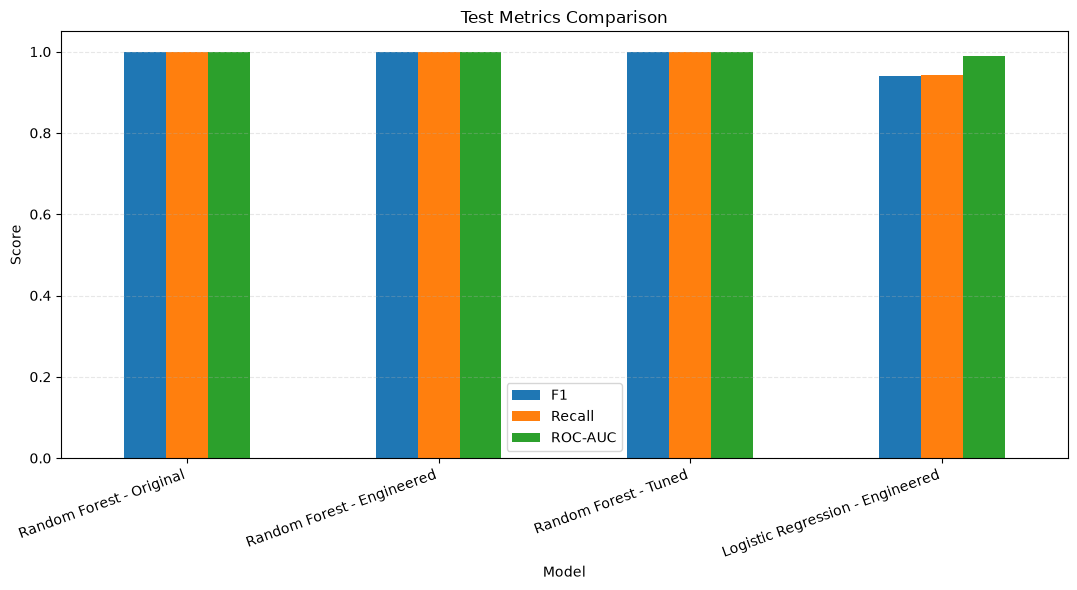

In [ ]:
plot_results = results.set_index('Model')[['F1', 'Recall', 'ROC-AUC']]

plot_results.plot(kind='bar', figsize=(11, 6))

plt.title('Test Metrics Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.05)

plt.xticks(rotation=20, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

#### Confusion matrices:

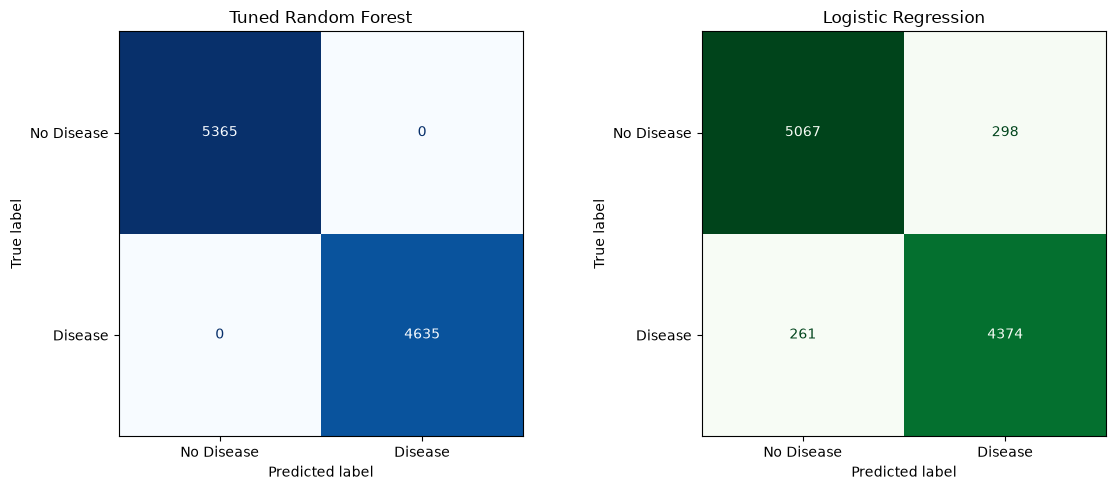

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, pred_rf),
    display_labels=['No Disease', 'Disease']
).plot(ax=axes[0], cmap='Blues', colorbar=False)

axes[0].set_title('Tuned Random Forest')

ConfusionMatrixDisplay(
    confusion_matrix(y_test, pred_lr),
    display_labels=['No Disease', 'Disease']
).plot(ax=axes[1], cmap='Greens', colorbar=False)

axes[1].set_title('Logistic Regression')

plt.tight_layout()
plt.show()

##### False positives and false negatives:

- False Positive (FP): predicts heart disease when the actual class is 0.
- False Negative (FN): predicts no heart disease when the actual class is 1.

The false negatives are useful to check because they are positive heart disease cases that the model missed.

In [145]:
predictions = {
    'Random Forest - Original': pred_original,
    'Random Forest - Engineered': pred_engineered,
    'Random Forest - Tuned': pred_rf,
    'Logistic Regression - Engineered': pred_lr
}

for name, pred in predictions.items():
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    print(f'{name}: FP = {fp}, FN = {fn}, TP = {tp}, TN = {tn}')

Random Forest - Original: FP = 0, FN = 0, TP = 4635, TN = 5365
Random Forest - Engineered: FP = 0, FN = 0, TP = 4635, TN = 5365
Random Forest - Tuned: FP = 0, FN = 0, TP = 4635, TN = 5365
Logistic Regression - Engineered: FP = 298, FN = 261, TP = 4374, TN = 5067


#### ROC curves:

ROC-AUC compares how well the models separate the two classes across different thresholds.

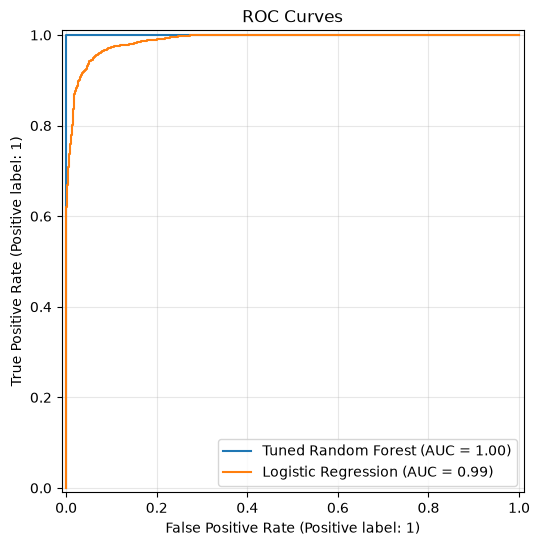

In [146]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, prob_rf, name='Tuned Random Forest', ax=ax)
RocCurveDisplay.from_predictions(y_test, prob_lr, name='Logistic Regression', ax=ax)

plt.title('ROC Curves')
plt.grid(alpha=0.3)
plt.show()

## Random Forest feature importance

The pipeline changes the feature names after one-hot encoding, so the transformed names are taken from the preprocessor before plotting the importances.

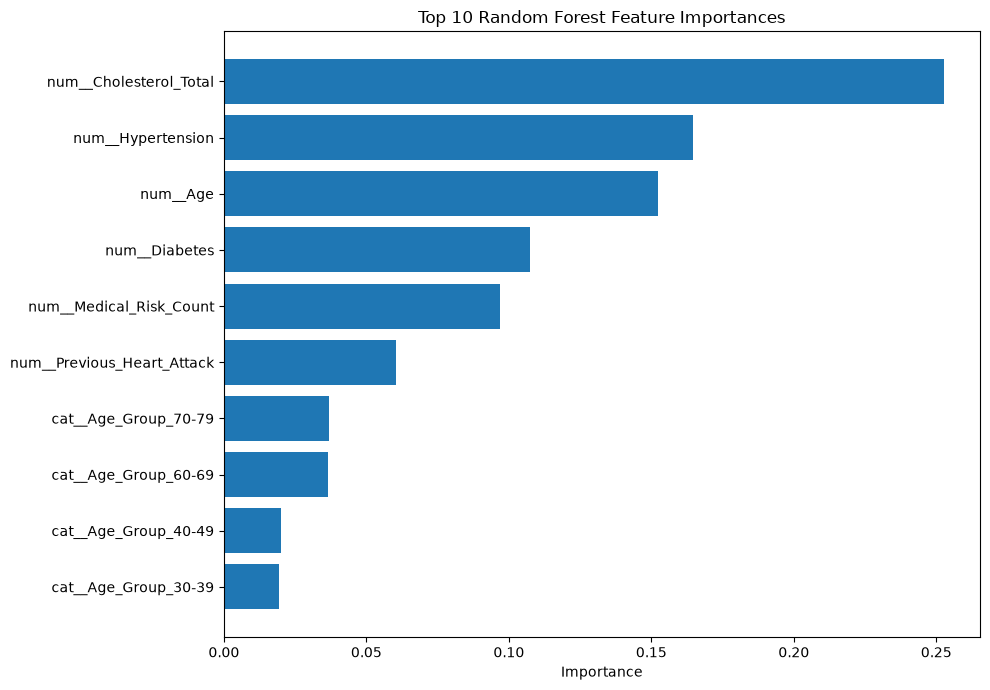

,Feature,Importance
13,num__Cholesterol_Total,0.252696
4,num__Hypertension,0.164639
0,num__Age,0.152323
5,num__Diabetes,0.107519
16,num__Medical_Risk_Count,0.097045
8,num__Previous_Heart_Attack,0.060302
39,cat__Age_Group_70-79,0.036919
38,cat__Age_Group_60-69,0.036550
36,cat__Age_Group_40-49,0.020090
35,cat__Age_Group_30-39,0.019339


In [147]:
rf_preprocessor = best_rf.named_steps['preprocessor']

rf_model = best_rf.named_steps['model']

feature_names = rf_preprocessor.get_feature_names_out()

rf_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(10)

plot_data = rf_importances.sort_values(by='Importance')
plt.figure(figsize=(10, 7))
plt.barh(plot_data['Feature'], plot_data['Importance'])
plt.title('Top 10 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

rf_importances

## Final comparison

The important comparison here is not only tuned vs untuned. The main questions are:

- Did the engineered features improve cross-validation F1?
- Does the tuned Random Forest improve over the untuned engineered pipeline?
- How does Random Forest compare with Logistic Regression on the same test set?
- Are the cross-validation and test results close to each other?

A model should not be chosen using accuracy alone. F1, recall, ROC-AUC and the confusion matrix should also be checked.

In [148]:
summary = pd.DataFrame({
    'Experiment': [
        'Random Forest - Original Features',
        'Random Forest - Engineered Features',
        'Random Forest - Tuned',
        'Logistic Regression - Engineered Features'
    ],
    'CV F1': [
        original_scores.mean(),
        engineered_scores.mean(),
        grid_rf.best_score_,
        lr_scores.mean()
    ],
    'CV Std': [
        original_scores.std(),
        engineered_scores.std(),
        grid_rf.cv_results_['std_test_score'][grid_rf.best_index_],
        lr_scores.std()
    ],
    'Test F1': [
        f1_score(y_test, pred_original),
        f1_score(y_test, pred_engineered),
        f1_score(y_test, pred_rf),
        f1_score(y_test, pred_lr)
    ]
})

summary.round(4)

,Experiment,CV F1,CV Std,Test F1
0,Random Forest - Original Features,1.0000,0.000,1.0000
1,Random Forest - Engineered Features,1.0000,0.000,1.0000
2,Random Forest - Tuned,1.0000,0.000,1.0000
3,Logistic Regression - Engineered Features,0.9446,0.001,0.9399


#### Cross-validation vs test F1:

The CV and test F1 scores should be reasonably close. A large gap can be a sign of overfitting.

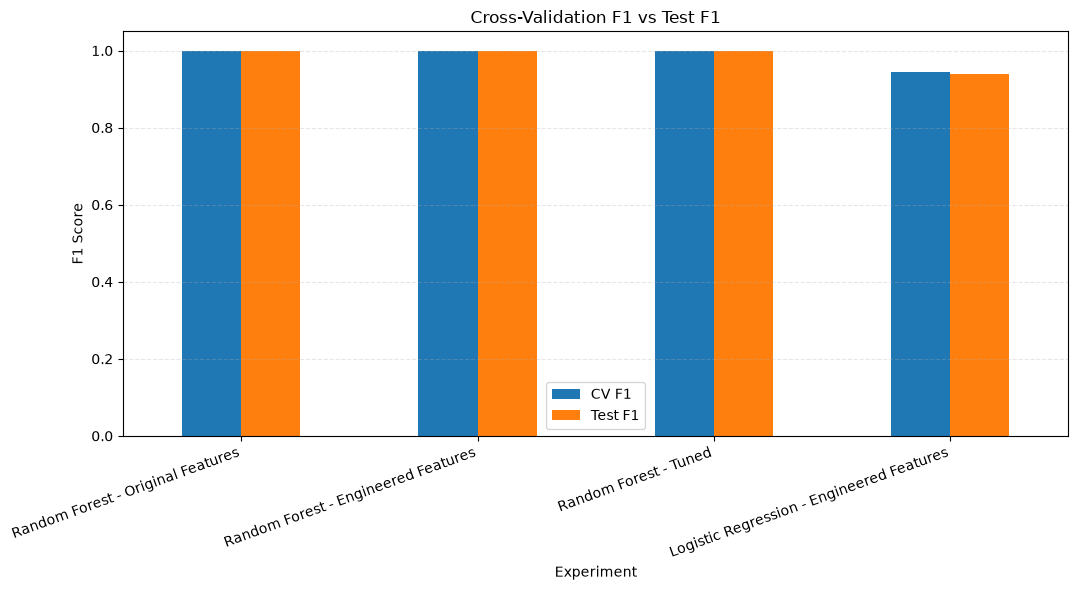

In [149]:
comparison_plot = summary.set_index('Experiment')[['CV F1', 'Test F1']]

comparison_plot.plot(kind='bar', figsize=(11, 6))
plt.title('Cross-Validation F1 vs Test F1')
plt.ylabel('F1 Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

#### Final notes:

- If engineered features do not improve the score, that does not mean the feature engineering step failed. It means the original features already contained most of the useful information.
- A very small difference between the original and engineered models can still be reported.
- Because this is synthetic data, unusually high model performance should be interpreted carefully.

### A check for the perfect tree scores

The Random Forest gives an F1 score of 1.0 even with cross-validation.

I checked whether this was caused by preprocessing leakage. The preprocessing is fitted only inside each pipeline and the test set is kept separate.

A small Decision Tree can also separate the target almost perfectly, which suggests that the synthetic target follows a simple rule based on a few features rather than the score coming from data leakage.